# DAI Mission — Proposal
**Data & AI in Economics | TU Dortmund**


## 1. Team

| Role | Name               | Student ID |
|------|--------------------|------------|
| Lead | Emma Kliushnichenko | 242989     |
| Member | Mohamed Gomaa | 283950     |
| Member  | Ahmed Abdelrazek | 284304     |


## 2. Mission Title & Research Question

**Title:** *[Gender Differences in Executive Roles based on BoardEx Europe data]*

**Research question:**  

Which individual characteristics, including education, age, nationality, professional experience, board experience, committee involvement, and network position, influence the probability of holding a top position in a company, and does gender remain associated with this probability after investigating on these factors?


**Why it matters:**  

As a data scientist student, I became interested in salary levels in IT. Based on the data from Kununu, a salary gap between men and women still exists in Germany. According to their public information, female data scientists earn around 2,000 euros less per year than male data scientists.

Gender inequality has already been studied by many researchers. For example, the recent work of Nobel Prize winner Claudia Goldin on gender gaps in career outcomes highlights the systematic nature of wage inequality, not only in the USA but also in other countries. Gender inequality in labor markets is not only reflected in employment rates or salaries, but also in access to high responsibility positions.

This project studies whether such differences are visible among directors and executives in European organizations. The main focus is on whether women and men differ in their access to top roles.


## 3. Data

**Source(s):**  
The project uses BoardEx Europe data accessed through Wharton Research Data Services (WRDS). BoardEx-Europe provides information on 1.7 million corporate executives and board members from over 2.2 million organizations based in Europe. The data are used for academic purposes under the access terms of WRDS and BoardEx. Access is provided through the TU Dortmund institutional licence.

**URL:** https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/  

The files are used:

- `individual_profile_education.csv`: recorded education
- `individual_profile_employment.csv`: employment and roles in the company
- `individual_profile_details.csv`: demographic information
- `board_and_director_committees.csv`: board and committee roles
- `individual_networks.csv`: professional networks
- `company_profile.csv`: information about companies
- `annual_remuneration.csv`: compensation information

**Unit of observation:**  

The main unit of observation is the role in a company from `individual_profile_employment.csv`. All tables are merged by `directorid`, and tables that are related to companies data are merged by `companyid` or by both `directorid` and `companyid`. One director can have several role records, and one company can be connected to many directors.


**Key variables:**  

| Variable / group | Type           | Role | Description |
|---|----------------|---|---|
| `directorid` | Numeric        | ID | Individual identifier. |
| `directorname` | Text           | ID | Individual name. |
| `companyid` | Numeric        | ID | Company identifier. |
| `companyname` | Text           | ID | Company name. |
| `gender`, `female` | Categorical    | Feature | Gender and female indicator. |
| `rolename`, `rolename_clean` | Text           | Feature | Role title. |
| `is_ceo`, `is_cfo`, `is_coo`, `is_cto_cio`, `is_other_csuite`, `is_president`, `is_md`, `is_executive`, `is_senior_management`, `has_any_executive_role` | Binary         | Target | Executive and senior leadership indicators. |
| `brdposition`, `brdposition_binary`, `ned`, `ned_binary`, `is_board_member_ed`, `is_board_member_sd`, `is_ned`, `is_independent_director`, `is_nonexecutive_independent`, `is_chairman` | Binary         | Control | Board, non-executive, independent, and chairman indicators. |
| `is_committee_member`, `is_advisor`, `is_consultant`, `is_partner`, `is_founder`, `is_owner_investor`, `is_employee_representative`, `is_manager_operational` | Binary         | Feature | Additional role indicators. |
| `is_unclassified_role`, `role_indicator_sum` | Numeric        | Quality | Checks missed or overlapping role classifications. |
| `leadershipteam`, `leadershipteam_binary` | Binary         | Target | Leadership status. |
| `hocountryname` | Categorical    | Control | Company head-office country. |
| `orgtype`, `orgtype_company` | Categorical    | Control | Organization type. |
| `sector_company` | Categorical    | Control | Company sector. |
| `age` | Numeric        | Control | Individual age. |
| `nationality` | Categorical    | Control | Individual nationality. |
| `num_qualifications`, `qualifications_raw`, `has_mba`, `has_phd`, `has_master`, `has_bachelor` | Numeric/Binary | Feature | Education information. |
| `datestartrole`, `dateendrole`, `start_year`, `end_year`, `role_active_currently` | Date           | Filter | Role timing and current-role indicator. |

**Note**:  The role indicators were created by one-hot encoding selected values from `rolename` and `rolename_clean`. This means that role titles were transformed into binary variables, such as `is_ceo`, `is_cfo`, `is_coo`, `is_board_member_ed`, and `has_any_executive_role`, where 1 indicates that the observation belongs to that role category and 0 otherwise. The same approach was also used for education variables, where recorded qualifications were transformed into binary indicators such as `has_mba`, `has_phd`, `has_master`, and `has_bachelor`.


### Potential data quality issues

The final dataset contains **1,507,568 observations**, **56 variables**, **322,747 unique director IDs**, and **489,540 unique company IDs**.

##### Missing values

`fulltextdescription` is 65.71% missing, `nationality` is 61.80% missing, `sector_company` is 42.72% missing, and `age` is 37.25% missing. Education variables are available for only about **19.93–19.94%** of observations. They are kept because they are relevant.

There are 7 missing values in the gender data. Since this is a very small part of the whole dataset and the reason for these missing values could not be identified, these observations will be removed.

##### Placeholders

In `datestartrole`, `1900-01-01` likely indicates an unknown start date. In `dateendrole`, `9000-01-01` and `9999-12-31` likely indicate ongoing roles and contain most of the data, so we will not use exact end dates as reliable values. However, we will still look at ongoing roles.

##### Selection bias

Some datasets, such as Individual Profile Employment and Annual Remuneration, were downloaded for **2016–2026**, while other files do not clearly specify the same time period. Annual Remuneration was almost entirely missing after merging, so compensation variables were removed from the main project.

##### Measurement error

The **gender distribution is unequal**. The dataset includes **1,210,252 male observations** and **297,309 female observations**. The analysis will use scaled measures to account for this gap.


##### Flagged features

Some role indicators, such as CEO etc. were created manually from `rolename`. Since job titles are not always standardized, some roles may be missed and assigned to more than one category. Therefore, `is_unclassified_role` and `role_indicator_sum` are used only as checks for the role classification.


In [ ]:
import pandas as pd
import numpy as np

path = "/Users/emma_kliushnichenko/Desktop/data and ai in economics/"

df = pd.read_csv(path + "data.csv", low_memory=False)

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Unique id directors:", df["directorid"].nunique())
print("Unique id companies:", df["companyid"].nunique())

df.head()

Rows: 1507568
Columns: 56
Unique id directors: 322747
Unique id companies: 489540


,directorid,directorname,companyid,companyname,gender,female,datestartrole,dateendrole,rolename,rolename_clean,...,sector_company,orgtype_company,cccountryname,fulltextdescription,num_qualifications,qualifications_raw,has_mba,has_phd,has_master,has_bachelor
0,328039,William Burgess,10,FIRST ACTIVE PLC (De-listed 01/2004),M,0.0,1900-01-01,9999-12-31,NED,ned,...,NaN,Quoted,Unknown,NaN,2.0,Degree; Fellow,0.0,0.0,0.0,0.0
1,885377,Doctor António Palma Ramalho,10,FIRST ACTIVE PLC (De-listed 01/2004),M,0.0,1900-01-01,9999-12-31,Director - SD,director - sd,...,NaN,Quoted,Unknown,NaN,3.0,Graduated; MSc; Postgraduate Degree,0.0,0.0,1.0,0.0
2,2765991,Clodagh NicCanna,10,FIRST ACTIVE PLC (De-listed 01/2004),F,1.0,1900-01-01,9999-12-31,Executive,executive,...,NaN,Quoted,Unknown,NaN,2.0,BSc; MSc,0.0,0.0,1.0,1.0
3,1321349,David Young,11,First Agate Capital Corp,M,0.0,2018-06-01,9000-01-01,Managing Partner,managing partner,...,NaN,NaN,NaN,NaN,1.0,BA (Cum Laude),0.0,0.0,0.0,1.0
4,1261572,Adam Ebrahim,11,First Agate Capital Corp,M,0.0,1900-01-01,9999-12-31,Director - SD,director - sd,...,NaN,NaN,NaN,NaN,5.0,BSocSc (Bachelor of Social Sciences); Certifie...,0.0,0.0,1.0,1.0


In [ ]:
## Missing data percentage

print(
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

fulltextdescription            65.71
nationality                    61.80
cccountryname                  46.74
sector_company                 42.72
age                            37.25
orgtype_company                25.57
qualifications_raw             19.94
num_qualifications             19.93
has_bachelor                   19.93
has_mba                        19.93
has_phd                        19.93
has_master                     19.93
brdposition_binary              0.18
hocountryname                   0.11
orgtype                         0.11
gender                          0.00
female                          0.00
is_owner_investor               0.00
is_committee_member             0.00
is_advisor                      0.00
is_consultant                   0.00
is_partner                      0.00
is_founder                      0.00
has_any_executive_role          0.00
is_employee_representative      0.00
is_manager_operational          0.00
is_unclassified_role            0.00
r

In [ ]:
## Gender distribution

display(df["gender"].value_counts(dropna=False).reset_index(name="N"))

,gender,N
0,M,1210252
1,F,297309
2,NaN,7


In [ ]:
## Missing values by gender

gender_NaN= df[df["gender"].isna()].copy()

len(gender_NaN)

cols_to_show = [
    "directorid",
    "companyid",
    "rolename",
    "datestartrole",
    "dateendrole",
    "brdposition",
    "ned",
    "leadershipteam",
    "hocountryname",
    "orgtype",
    "age",
    "nationality"
]

cols_to_show = [c for c in cols_to_show if c in missing_gender.columns]

gender_NaN[cols_to_show]

,directorid,companyid,rolename,datestartrole,dateendrole,brdposition,ned,leadershipteam,hocountryname,orgtype,age,nationality
143999,3064769,28755,Deputy Employee Representative,2025-05-27,9000-01-01,No,No,No,Norway,Quoted,NaN,NaN
144000,3064771,28755,Deputy Employee Representative,2025-05-27,9000-01-01,No,No,No,Norway,Quoted,NaN,NaN
144001,3064765,28755,Deputy Employee Representative,2025-05-27,9000-01-01,No,No,No,Norway,Quoted,NaN,NaN
581845,3011921,1260886,Executive,1900-01-01,9999-12-31,No,No,No,Turkey,Private,NaN,NaN
698789,3011921,1676917,Marketing Director,1900-01-01,9999-12-31,No,No,No,Italy,Private,NaN,NaN
1482374,3011921,3957992,Marketing Director,1900-01-01,9000-01-01,No,No,No,Turkey,Quoted,NaN,NaN
1498370,3190364,4053952,Executive,1900-01-01,9000-01-01,No,No,No,Germany,Private,NaN,NaN


In [ ]:
# Investigate start/end role dates

date_cols = ["datestartrole", "dateendrole"]


print(df[date_cols].value_counts(dropna=False).head(20))


datestartrole  dateendrole
1900-01-01     9999-12-31     304211
               9000-01-01     135544
2022-01-01     9000-01-01       9210
2023-01-01     9000-01-01       8861
2021-01-01     9000-01-01       8210
2020-01-01     9000-01-01       7829
2024-01-01     9000-01-01       7629
2019-01-01     9000-01-01       7531
2018-01-01     9000-01-01       6808
2017-01-01     9000-01-01       6005
2016-01-01     9000-01-01       5533
2015-01-01     9000-01-01       5019
2014-01-01     9000-01-01       4638
2025-01-01     9000-01-01       4419
2013-01-01     9000-01-01       4294
2012-01-01     9000-01-01       3927
2011-01-01     9000-01-01       3654
2010-01-01     9000-01-01       3408
2009-01-01     9000-01-01       3092
2008-01-01     9000-01-01       2933
Name: count, dtype: int64


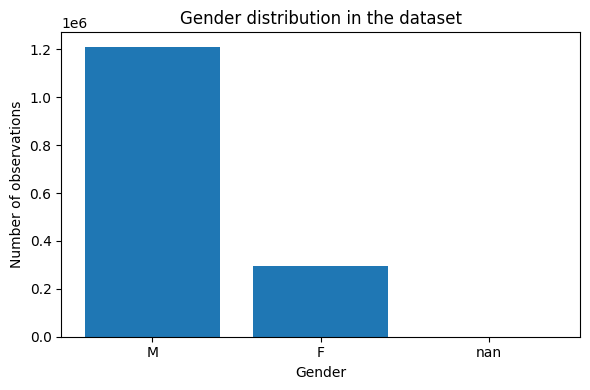

In [ ]:
## Gender distribution

gender_counts = (
    df["gender"]
    .value_counts(dropna=False)
    .reset_index(name="N")
    .rename(columns={"gender": "Gender"})
)


plt.figure(figsize=(6, 4))

plt.bar(
    gender_counts["Gender"].astype(str),
    gender_counts["N"]
)

plt.xlabel("Gender")
plt.ylabel("Number of observations")
plt.title("Gender distribution in the dataset")
plt.tight_layout()

plt.show()

## 4. Planned Methods



### 4a. Causal Inference

- [x] Causal graph / DAG

- [x] Backdoor adjustment

- [ ] Instrumental variable

- [x] Propensity score stratification

- [ ] Other: ___

**Justification:**

The DAG represents the assumed pathways between gender and access to leadership roles. The variable is `female`, and the outcome is access to top roles, measured by variables such as `has_any_executive_role` or `leadershipteam_binary`.

The graph assumes that gender may be associated with access to the top positions directly, but also indirectly through career and organizational mechanisms. Education, sector, board status, role status and network positions may act as mediators.

Age, nationality, company head-office country, sector, and organization type are included as observed adjustment variables. However, these observed adjustment variables are not sufficient to remove all confounding. The variable `U` represents unobserved factors that are not presented in the dataset. These may include ambition, career preferences, family constraints, hiring culture, and board nomination practices. Because such factors are not observed, the analysis will not claim a definitive causal effect of gender. Instead, the DAG is used to make the assumptions explicit and to estimate an adjusted gender gap under these assumptions.

Additionally, we can use propensity score stratification. First, the propensity score is estimated as the probability of being recorded as female conditional on the observed adjustment variables. Individuals are then divided into strata with similar propensity scores. Within each stratum, the probability of holding a top role is compared between women and men. The final estimate is the weighted average of these specific differences within stratum. This estimate is interpreted as an adjusted gender disparity, not as a definitive causal effect.

To assess robustness, refutation tests will be implemented in DoWhy. A random common cause refuter can be used by adding a randomly generated confounder to the model. We will replace real treatment variable female with a randomly assigned placebo treatment. If the estimated effect does not change substantially, this supports the stability of the result.

### 4b. Supervised Learning
- [x] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:*  

Logistic regression is selected because it is interpretable and suitable for binary outcomes. The main outcome will be `has_any_executive_role`, which indicates whether a person holds a high position. Additional binary outcomes such as `leadershipteam_binary`, `is_ceo`, `is_cfo`, `is_coo`, `is_board_member_ed`, and `is_senior_management`, etc. It allows the coefficient of `female` to be interpreted as the association between gender and the probability of holding an executive or leadership role, conditional on other variables.

Lasso logistic regression will be used as a regularized version of logistic regression. It is useful because the dataset contains many binary role indicators and control variables. Lasso can shrink less important coefficients toward zero, helping with feature selection and making the model easier to interpret in the report.

Random Forest will be used as a more flexible model that can capture non-linear relationships and interactions between variables. It also provides feature importance, which is useful for identifying which variables are most relevant for predicting executive-role access.

### 4c. Unsupervised Learning / Generative Models

- [ ] K-Means clustering

- [x] Hierarchical clustering

- [ ] Variational autoencoder

- [ ] GAN

- [ ] Other: ___

**Justification:**

Hierarchical clustering is selected instead of K-Means because K-Means can be sensitive to random initialization and may work poorly on very large and mixed datasets. It is more useful for exploring whether observations form nested groups.

The clustering will be applied to variables that describe the individual and organizational context but do not directly define the target outcome. These include age, nationality, company head-office country, organization type, sector, education, board status, committee membership, and other non-executive role context indicators. Outcome variables such as has_any_executive_role, leadershipteam_binary, and the top role indicators will not be used for clustering if the resulting cluster labels are later used in supervised models, in order to avoid target leakage.

After clusters are created, the gender distribution and the distribution of education, board status, sector, and organization type within each cluster will be compared. This allows the clusters to be interpreted as meaningful groups rather than only technical outputs of the clustering algorithm.

The clustering block is connected to the supervised learning block by using the cluster identities as additional features. Supervised models will first be trained without cluster labels and then with cluster labels. Comparing model performance across these specifications, using metrics such as AUC, F1-score, precision, and recall, will show whether the unsupervised latent groups provide additional predictive information for access to top executive roles.

Finally, the clusters can help the causal analysis in exploring heterogeneous effect. The project can test whether the gender gap is stronger in some clusters than in others by comparing the association between `female` and `has_any_executive_role` within different clusters.

## 5. Evaluation Strategy


The mission will be considered successful if the analysis can identify and explain gender differences in access to the high positions in the companies.

For supervised learning, the models will be evaluated using cross-validation. Logistic regression, Lasso logistic regression, and Random Forest will be compared using the same main evaluation metrics: accuracy, precision, recall, F1-score, and AUC. AUC and F1-score will be especially important, because there is a data imbalance. A simple baseline model, such as predicting the majority class, will be used as a benchmark.

Logistic regression will be used as the main interpretable model. Lasso logistic regression will be compared to logistic regression to check whether regularization and feature selection improve the performance. Random Forest will be compared to both to test whether it improves predictive performance.

For unsupervised learning, hierarchical clustering will be evaluated using cluster interpretability and descriptive comparison across clusters. If possible, silhouette score will be used. The clusters will be examined by comparing gender shares within each cluster.



## 6. Work Plan

| Step | Owner | Description                     |
|------|-------|---------------------------------|
| 1 | Emma  | Data collection & cleaning      |
| 2 | Emma  | EDA                             |
| 3 | Mohamed / Ahmed      | Causal inference block          |
| 4 | Mohamed / Ahmed      | Supervised learning block       |
| 5 | Mohamed / Ahmed      | Unsupervised / generative block |
| 6 | Emma  | Synthesis & write-up            |
